# **DATASET INFORMATION**

**Dataset:** `company_data.csv`  
Dataset ini berisi indikator performa keuangan dan pasar dari 1.000 perusahaan, meliputi:
- `company_id`: ID unik perusahaan
- `price`: Harga saham saat ini
- `volume`: Volume perdagangan saham harian
- `pe_ratio`: Rasio harga terhadap laba (*Price to Earnings Ratio*)
- `revenue`: Total pendapatan tahunan perusahaan
- `profit`: Total laba bersih tahunan perusahaan
- `employees`: Jumlah total karyawan

### 1. Mengimpor Library yang Dibutuhkan
Pada tahap ini kita memuat pustaka utama Python untuk pengolahan data (`pandas`, `numpy`) serta pustaka visualisasi grafik (`matplotlib`, `seaborn`).

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi gaya tampilan grafik
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
print("Semua library berhasil dimuat!")

Semua library berhasil dimuat!


### 2. Memuat Dataset Mentah (*Raw Data*)
Membaca file `company_data.csv` dan melihat sampel data teratas.

In [14]:
df_raw = pd.read_csv('company_data.csv')
print(f"Dimensi Dataset: {df_raw.shape[0]} baris dan {df_raw.shape[1]} kolom.")
df_raw.head(10)

Dimensi Dataset: 1000 baris dan 7 kolom.


,company_id,price,volume,pe_ratio,revenue,profit,employees
0,1,1935.246582,3397291,29.754137,4229.176886,18748.468004,49278
1,2,4758.500101,3902429,22.489376,6712.589913,6304.862525,138109
2,3,3686.770315,4994287,12.365771,44992.169575,5070.466033,122052
3,4,3033.426573,2590706,17.320609,28279.245983,13117.787070,39986
4,5,864.491338,1291902,46.774289,62581.916675,12422.856738,49799
5,6,864.373150,2592118,35.419202,99251.786648,6708.984688,76496
6,7,384.609700,3837973,27.322153,39245.994135,18569.226527,90778
7,8,4344.263114,2302575,5.572170,57810.284156,16912.760317,25379
8,9,3045.463558,564071,49.658693,42144.785695,4557.252663,169278
9,10,3569.555631,4481137,35.215472,84879.895104,4858.936654,110876


### 3. Pemeriksaan Struktur dan Kualitas Data
Mengecek tipe data setiap kolom, ketiadaan nilai (*missing values / null*), dan baris duplikat.

In [15]:
print(" INFORMASI DATASET ")
df_raw.info()

print("\n JUMLAH MISSING VALUES PER KOLOM ")
print(df_raw.isnull().sum())

print("\n JUMLAH BARIS DUPLIKAT ")
print(f"Duplikat: {df_raw.duplicated().sum()}")

 INFORMASI DATASET 
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   company_id  1000 non-null   int64  
 1   price       1000 non-null   float64
 2   volume      1000 non-null   int64  
 3   pe_ratio    1000 non-null   float64
 4   revenue     1000 non-null   float64
 5   profit      1000 non-null   float64
 6   employees   1000 non-null   int64  
dtypes: float64(4), int64(3)
memory usage: 54.8 KB

 JUMLAH MISSING VALUES PER KOLOM 
company_id    0
price         0
volume        0
pe_ratio      0
revenue       0
profit        0
employees     0
dtype: int64

 JUMLAH BARIS DUPLIKAT 
Duplikat: 0


### 4. Pembersihan Data (*Data Cleaning*)
Langkah pembersihan yang dilakukan:
1. Memastikan standarisasi nama kolom menggunakan huruf kecil (*lowercase*) dan tanpa spasi liar, sebagaimana dicontohkan pada Modul 4.
2. Membulatkan angka pecahan (*floating points*) ke 2 angka di belakang koma untuk kemudahan interpretasi dan keterbacaan.

In [16]:
df = df_raw.copy()

# Standarisasi penamaan kolom (lowercase)
df.columns = [col.strip().lower() for col in df.columns]

# Pembulatan nilai float agar rapi
float_cols = ['price', 'pe_ratio', 'revenue', 'profit']
df[float_cols] = df[float_cols].round(2)

df.head()

,company_id,price,volume,pe_ratio,revenue,profit,employees
0,1,1935.25,3397291,29.75,4229.18,18748.47,49278
1,2,4758.50,3902429,22.49,6712.59,6304.86,138109
2,3,3686.77,4994287,12.37,44992.17,5070.47,122052
3,4,3033.43,2590706,17.32,28279.25,13117.79,39986
4,5,864.49,1291902,46.77,62581.92,12422.86,49799


### 5. Rekayasa Fitur (*Feature Engineering*)
Untuk menghasilkan visualisasi yang mendalam di aplikasi web Streamlit, kita menambahkan beberapa variabel bisnis penting:
1. **`profit_margin` (%)**: Mengukur rasio efisiensi keuntungan terhadap pendapatan: `(profit / revenue) * 100`.
2. **`rev_per_employee`**: Pendapatan per karyawan untuk mengukur produktivitas: `revenue / employees`.
3. **`valuation_status`**: Kategori valuasi berdasarkan Rasio P/E:
   - `< 15`: *Undervalued* (Harga saham dinilai murah/berpotensi *bargain*)
   - `15 - 30`: *Fair Value* (Valuasi wajar)
   - `> 30`: *Overvalued* (Valuasi tinggi / saham bertumbuh/mahal)
4. **`company_size`**: Skala ukuran perusahaan berdasarkan jumlah karyawan (*Small*, *Medium*, *Large*, *Enterprise*).

In [17]:
# Menghitung Profit Margin dan Revenue per Employee
df['profit_margin'] = ((df['profit'] / df['revenue']) * 100).round(2)
df['rev_per_employee'] = (df['revenue'] / df['employees']).round(4)

# Klasifikasi Valuasi P/E
def classify_valuation(pe):
    if pe < 15:
        return 'Undervalued'
    elif pe <= 30:
        return 'Fair Value'
    else:
        return 'Overvalued'

# Klasifikasi Skala Perusahaan
def classify_size(emp):
    if emp < 50000:
        return 'Small (<50k)'
    elif emp <= 100000:
        return 'Medium (50k-100k)'
    elif emp <= 150000:
        return 'Large (100k-150k)'
    else:
        return 'Enterprise (>150k)'

df['valuation_status'] = df['pe_ratio'].apply(classify_valuation)
df['company_size'] = df['employees'].apply(classify_size)

print("Distribusi Status Valuasi:")
print(df['valuation_status'].value_counts())
print("\nDistribusi Ukuran Perusahaan:")
print(df['company_size'].value_counts())
df.head()

Distribusi Status Valuasi:
valuation_status
Overvalued     462
Fair Value     314
Undervalued    224
Name: count, dtype: int64

Distribusi Ukuran Perusahaan:
company_size
Small (<50k)          257
Large (100k-150k)     256
Enterprise (>150k)    246
Medium (50k-100k)     241
Name: count, dtype: int64


,company_id,price,volume,pe_ratio,revenue,profit,employees,profit_margin,rev_per_employee,valuation_status,company_size
0,1,1935.25,3397291,29.75,4229.18,18748.47,49278,443.31,0.0858,Fair Value,Small (<50k)
1,2,4758.50,3902429,22.49,6712.59,6304.86,138109,93.93,0.0486,Fair Value,Large (100k-150k)
2,3,3686.77,4994287,12.37,44992.17,5070.47,122052,11.27,0.3686,Undervalued,Large (100k-150k)
3,4,3033.43,2590706,17.32,28279.25,13117.79,39986,46.39,0.7072,Fair Value,Small (<50k)
4,5,864.49,1291902,46.77,62581.92,12422.86,49799,19.85,1.2567,Overvalued,Small (<50k)


### 6. Statistik Deskriptif Dataset
Melihat ringkasan statistik (rata-rata, standar deviasi, kuartil, nilai min dan max) dari semua variabel numerik.

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
company_id,1000.0,5.005000e+02,2.888194e+02,1.0000,2.507500e+02,5.005000e+02,7.502500e+02,1.000000e+03
price,1000.0,2.502257e+03,1.431473e+03,122.7000,1.256267e+03,2.534355e+03,3.747168e+03,4.998620e+03
volume,1000.0,2.601082e+06,1.408695e+06,111303.0000,1.375310e+06,2.643212e+06,3.863455e+06,4.999856e+06
pe_ratio,1000.0,2.785900e+01,1.311924e+01,5.0100,1.629000e+01,2.873000e+01,3.912250e+01,4.999000e+01
revenue,1000.0,5.150690e+04,2.815050e+04,1199.8300,2.787689e+04,5.253679e+04,7.572173e+04,9.995485e+04
profit,1000.0,9.725499e+03,5.812282e+03,103.7100,4.724087e+03,9.447370e+03,1.483268e+04,1.995269e+04
employees,1000.0,1.002886e+05,5.774309e+04,463.0000,4.927250e+04,1.007945e+05,1.486515e+05,1.998570e+05
profit_margin,1000.0,4.305111e+01,9.709143e+01,0.1300,9.075000e+00,1.842500e+01,3.710750e+01,1.233730e+03
rev_per_employee,1000.0,1.612883e+00,5.813682e+00,0.0091,2.873000e-01,5.238000e-01,1.035650e+00,1.063042e+02


### 7. Exploratory Data Analysis (EDA) dan Visualisasi Data
Kita memvisualisasikan data ke dalam beberapa plot untuk melihat korelasi dan distribusi.

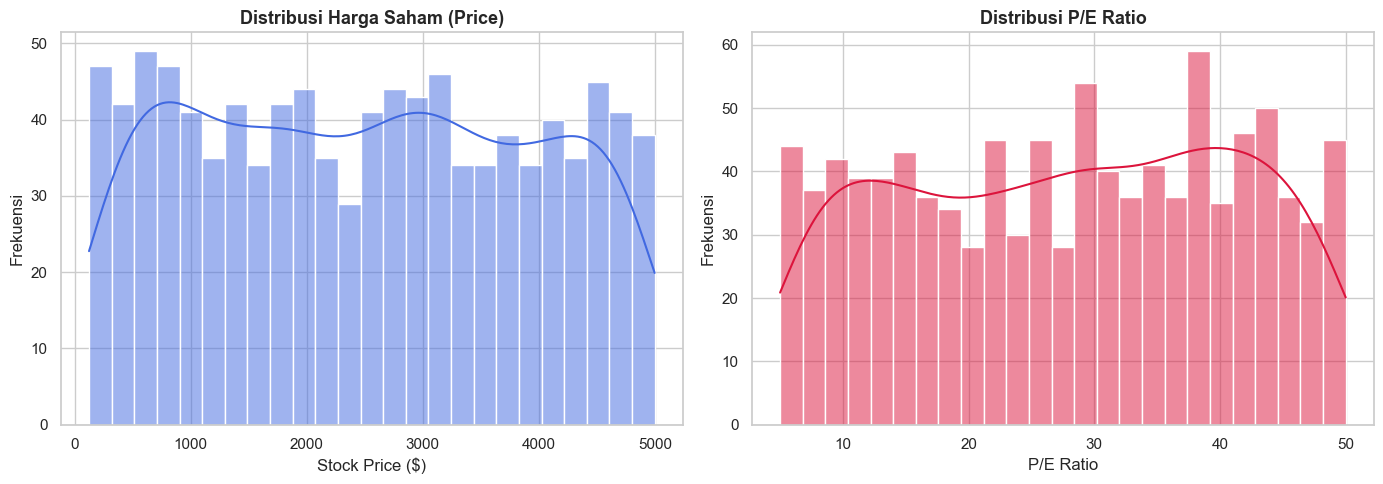

In [19]:
# Visualisasi 1: Distribusi Harga Saham dan Rasio P/E
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['price'], kde=True, ax=axes[0], color='royalblue', bins=25)
axes[0].set_title('Distribusi Harga Saham (Price)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Stock Price ($)')
axes[0].set_ylabel('Frekuensi')

sns.histplot(df['pe_ratio'], kde=True, ax=axes[1], color='crimson', bins=25)
axes[1].set_title('Distribusi P/E Ratio', fontsize=13, fontweight='bold')
axes[1].set_xlabel('P/E Ratio')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

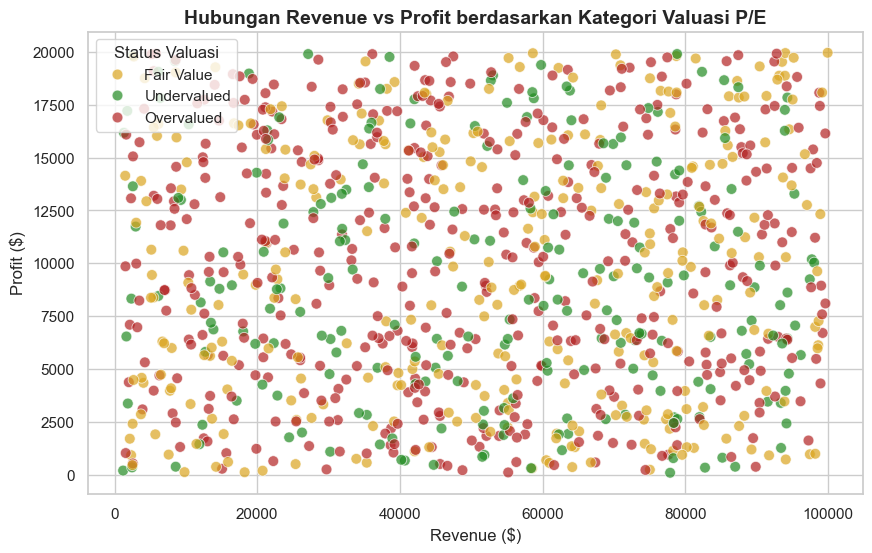

In [20]:
# Visualisasi 2: Hubungan Pendapatan (Revenue) vs Laba (Profit) berdasarkan Valuasi
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='revenue',
    y='profit',
    hue='valuation_status',
    palette={'Undervalued': 'forestgreen', 'Fair Value': 'goldenrod', 'Overvalued': 'firebrick'},
    alpha=0.7,
    s=60
)
plt.title('Hubungan Revenue vs Profit berdasarkan Kategori Valuasi P/E', fontsize=14, fontweight='bold')
plt.xlabel('Revenue ($)')
plt.ylabel('Profit ($)')
plt.legend(title='Status Valuasi')
plt.show()

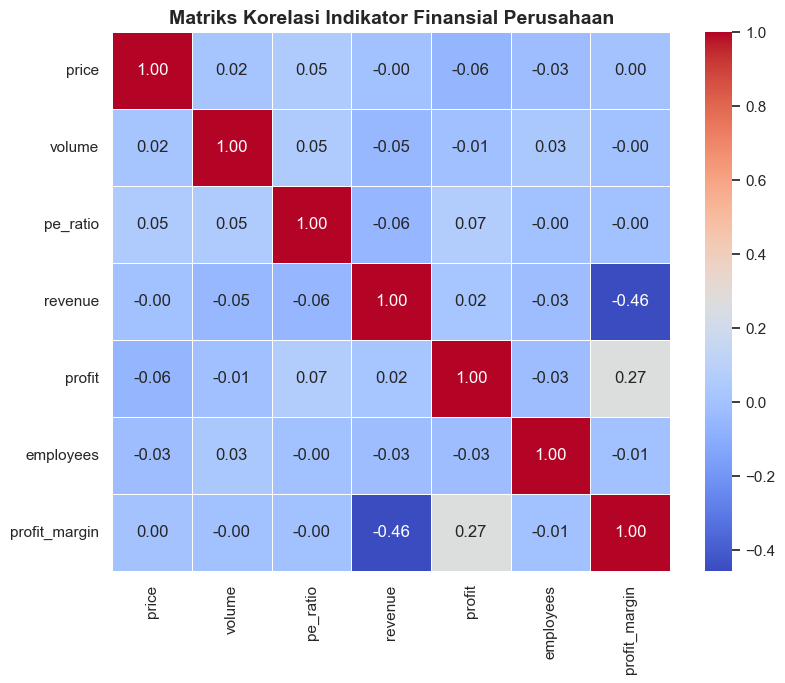

In [21]:
# Visualisasi 3: Matriks Korelasi Antar Fitur Numerik
plt.figure(figsize=(9, 7))
numeric_df = df[['price', 'volume', 'pe_ratio', 'revenue', 'profit', 'employees', 'profit_margin']]
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi Indikator Finansial Perusahaan', fontsize=14, fontweight='bold')
plt.show()

### 8. Menyimpan Dataset Bersih (*Cleaned Dataset*)
Dataset yang telah diproses dan diperkaya fitur disimpan ke `company_data_clean.csv` untuk diintegrasikan secara langsung ke dalam aplikasi web Streamlit.

In [22]:
df.to_csv('company_data_clean.csv', index=False)
print("Dataset bersih berhasil disimpan ke file 'company_data_clean.csv'!")

Dataset bersih berhasil disimpan ke file 'company_data_clean.csv'!
